In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\transcont\Export.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2630 entries, 0 to 2629
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2630 non-null   str  
 1   Message  2630 non-null   str  
 2   Status   2630 non-null   str  
dtypes: str(3)
memory usage: 61.8 KB


In [16]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252521    1682
0x252501     336
0x252511     334
0x252513     192
0x252514      86
Name: count, dtype: int64

In [17]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2630 entries, 0 to 2629
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2630 non-null   str  
 1   Message  2630 non-null   str  
 2   Status   2630 non-null   str  
 3   Headers  2630 non-null   str  
dtypes: str(4)
memory usage: 82.3 KB


Odometer

In [18]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 278 entries, 2 to 2586
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             278 non-null    str  
 1   Message             278 non-null    str  
 2   Status              278 non-null    str  
 3   Headers             278 non-null    str  
 4   Odometer in meters  278 non-null    int64
 5   Date                278 non-null    str  
 6   Raw data            278 non-null    str  
dtypes: int64(1), str(6)
memory usage: 17.4 KB
None


260723214220 -> 0 -> 24.0 -> 0x2525130059000A0869487060177580003C38402D00000064510000000000640000000000000000FFFFFFFFFFFF00D5000000181026072321422033137944560D99C2B0C85D400000000003331207FFFFFF000021FFFFFFFFFF
260723214534 -> 1 -> 24.0 -> 0x252514005900110869487060177580003C38402D0000005D490000000700644100000000000000FFFFFFFFFFFF16D50000001810260723214534CDCC6C415D8795C244912F410000000003531120FFFFFF0000230000FFFFFF
260723214635 -> 2 -> 24.0 -> 0x2525130059000B0869487060177580003C38402D00000060490000000700644100000000000000FFFFFFFFFFFF00D50000001810260723214635CDCC6C415D8795C244912F410000000003561359FFFFFF0000230000FFFFFF
260723214735 -> 3 -> 24.0 -> 0x2525130059000C0869487060177580003C38402D00000056480000000700644100000000000000FFFFFFFFFFFF00D50000001810260723214735CDCC6C415D8795C244912F410000000003591360FFFFFF0000230000FFFFFF
260723214835 -> 4 -> 24.0 -> 0x2525130059000D0869487060177580003C38402D000000644B0000000700644100000000000000FFFFFFFFFFFF00D50000001810260723214835CDCC6C415D879

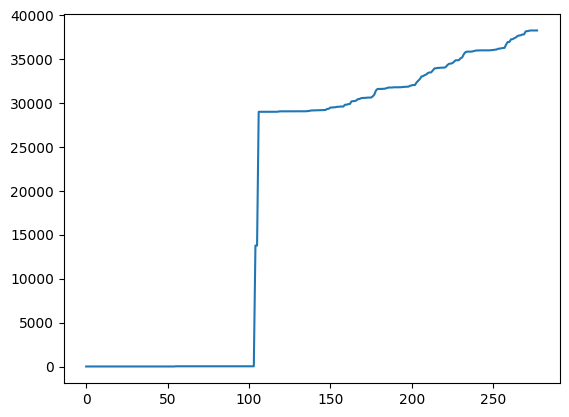

In [19]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [20]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 246 entries, 0 to 245
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     246 non-null    int64
 1   Date      246 non-null    str  
 2   Raw data  246 non-null    str  
dtypes: int64(1), str(2)
memory usage: 7.7 KB
None


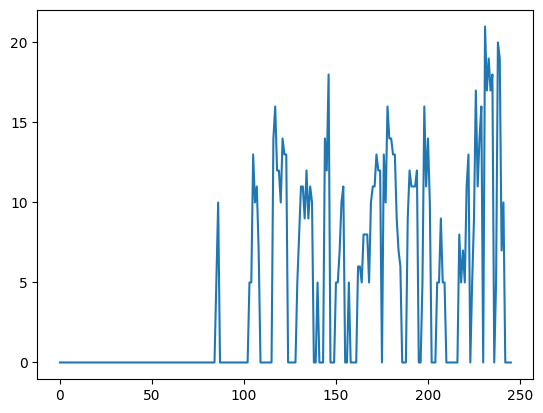

In [21]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historic events

In [22]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 278 entries, 2 to 2586
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         278 non-null    str  
 1   Message                         278 non-null    str  
 2   Status                          278 non-null    str  
 3   Headers                         278 non-null    str  
 4   Satellites                      278 non-null    int64
 5   Satellite_connection_indicator  278 non-null    int64
 6   Raw data                        278 non-null    str  
 7   date                            278 non-null    str  
dtypes: int64(2), str(6)
memory usage: 19.5 KB
128 -> 2026-07-23 21:53:32.576 -> 0 -> 0x252514005900140869487060177580003C38402D00000064800000000000640100000000000000FFFFFFFFFFFF19D5000000182426072321545682DC00650C00F201753C00E30000000003681384FFFFFF000024FFFFFFFFFF
128 -> 2026-07-23 21:53:32.446 -> 0 -> 0x2525130059001

Satellites number

In [23]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
odometer=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date
unit_aux['Odometer in meters']=odometer

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 278 entries, 2 to 2586
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         278 non-null    str  
 1   Message                         278 non-null    str  
 2   Status                          278 non-null    str  
 3   Headers                         278 non-null    str  
 4   Satellites                      278 non-null    int64
 5   Satellite_connection_indicator  278 non-null    int64
 6   Raw data                        278 non-null    str  
 7   date                            278 non-null    str  
 8   Odometer in meters              278 non-null    int64
dtypes: int64(3), str(6)
memory usage: 21.7 KB
128 -> 2026-07-23 21:53:32.576 -> 0 -> 0x252514005900140869487060177580003C38402D00000064800000000000640100000000000000FFFFFFFFFFFF19D5000000182426072321545682DC00650C00F201753C00E30000000003681384FFFFFF000024FFFFFF

Coordinates

In [24]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
odometer=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed
unit_aux['Odometer']=odometer

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8],unit.iloc[i,10],'->',unit.iloc[i,11])

<class 'pandas.DataFrame'>
Index: 278 entries, 2 to 2586
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            278 non-null    str    
 1   Message            278 non-null    str    
 2   Status             278 non-null    str    
 3   Headers            278 non-null    str    
 4   Latitude           278 non-null    str    
 5   Latitude_decoded   278 non-null    float64
 6   Longitude          278 non-null    str    
 7   Longitude_decoded  278 non-null    float64
 8   Raw data           278 non-null    str    
 9   Date               278 non-null    str    
 10  Speed              278 non-null    int64  
 11  Odometer           278 non-null    int64  
dtypes: float64(2), int64(2), str(8)
memory usage: 28.2 KB
None
260723214220 -> B0C85D40 -> 3.465373992919922 -> 560D99C2 -> -76.52604675292969 0x2525130059000A0869487060177580003C38402D00000064510000000000640000000000000000FFFFFFFFFFFF00

Filtered to 24-07-20026:

In [25]:
df_aux=unit[unit['Date'].str.contains('260724')]
df_aux[['Date','Latitude_decoded','Longitude_decoded','Speed','Odometer','Raw data']].to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\transcont\raw_data.csv', index=False)


In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [26]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\transcont\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 278 entries, 2 to 2586
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  278 non-null    str  
 1   Message  278 non-null    str  
 2   Status   278 non-null    str  
 3   Headers  278 non-null    str  
dtypes: str(4)
memory usage: 10.9 KB
